In [68]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
from palmerpenguins import load_penguins

sns.set_style("whitegrid")

In [4]:
data = load_penguins()
data.dropna(inplace=True)

In [7]:
data.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
 7   year               333 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 23.4 KB


# Visual examination

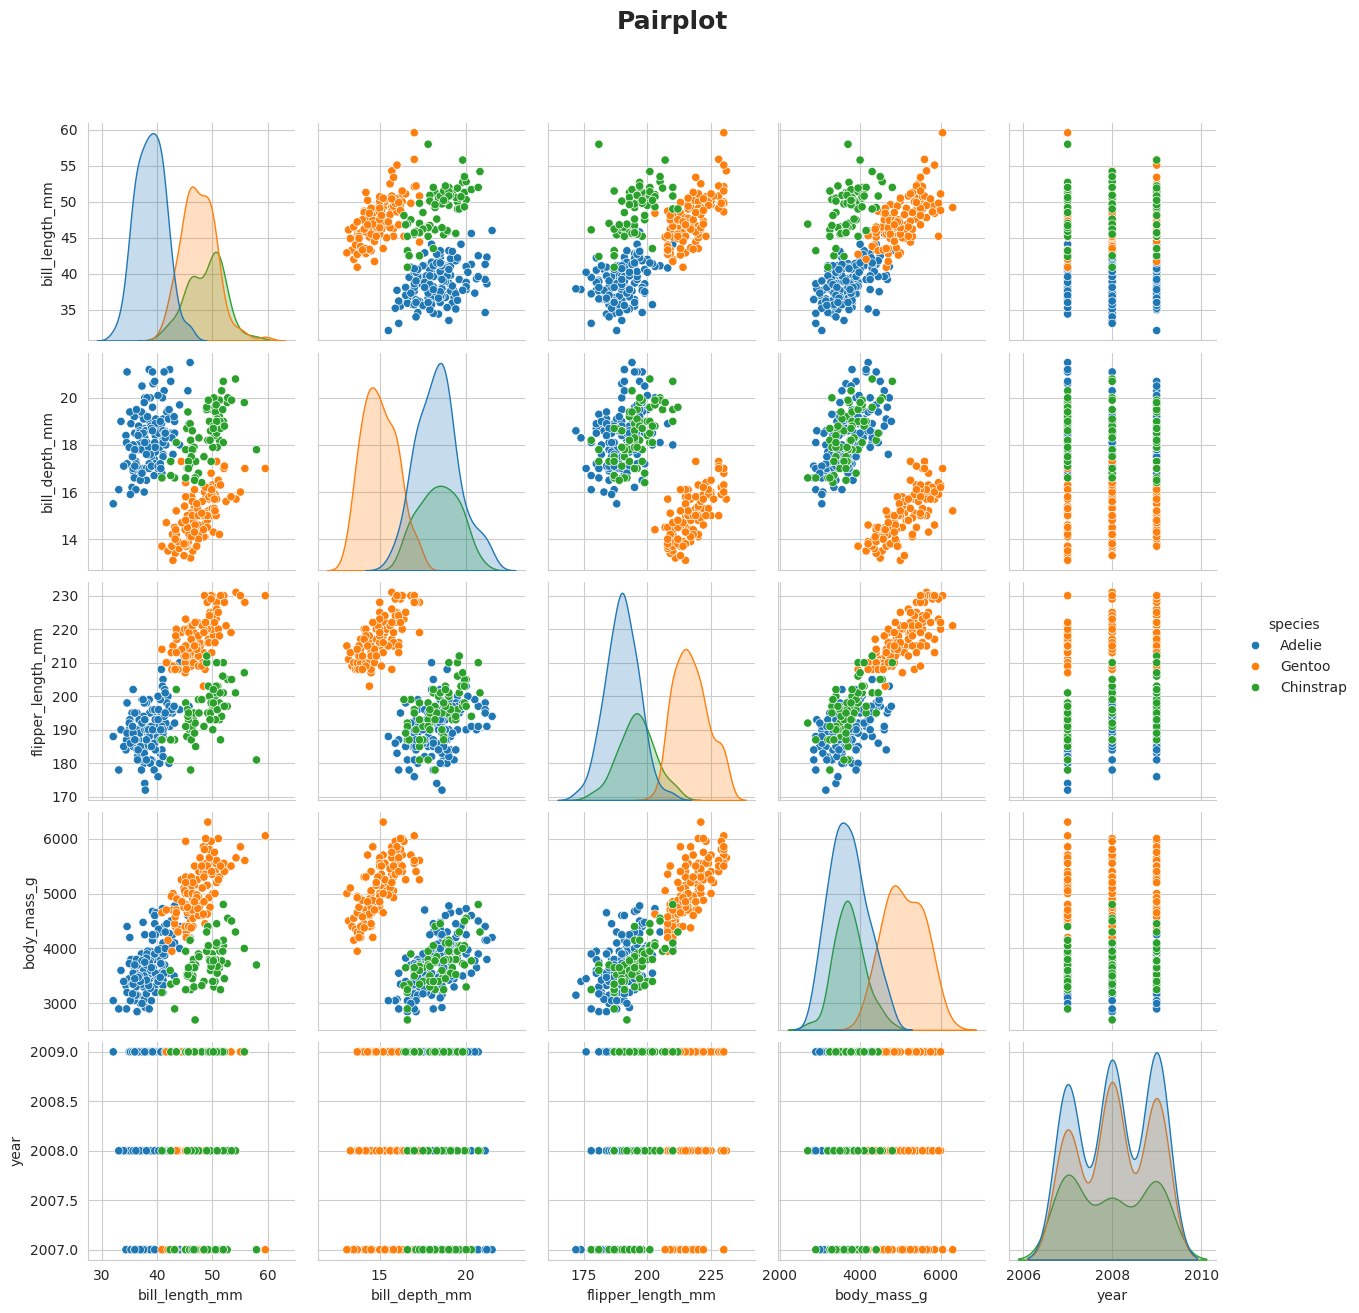

In [43]:
g = sns.pairplot(data, hue='species')
g.fig.suptitle('Pairplot', fontsize=18, fontweight='bold', y=1.05)
g.tight_layout()
plt.show()

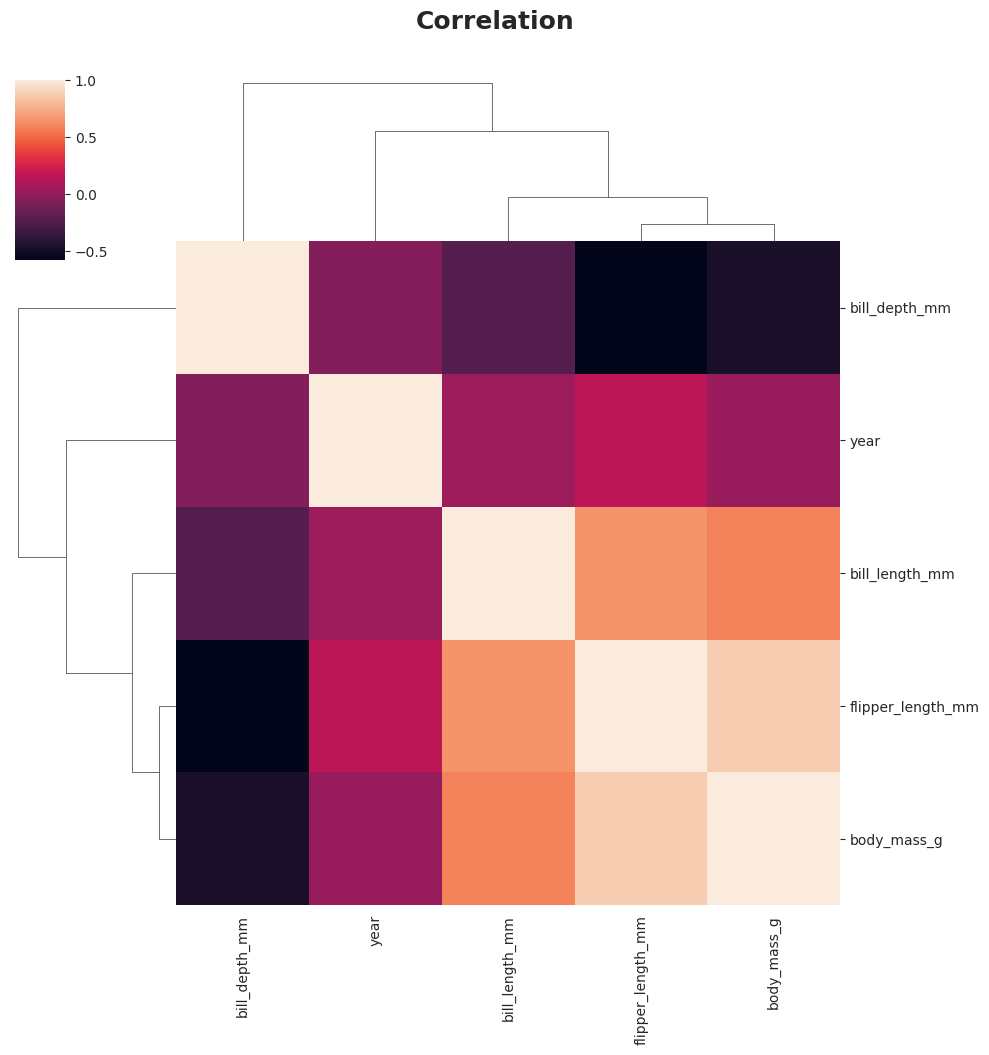

In [44]:
data_numeric = data.select_dtypes(include='number')
g = sns.clustermap(data_numeric.corr())
g.fig.suptitle('Correlation', fontsize=18, fontweight='bold', y=1.05)
plt.show()

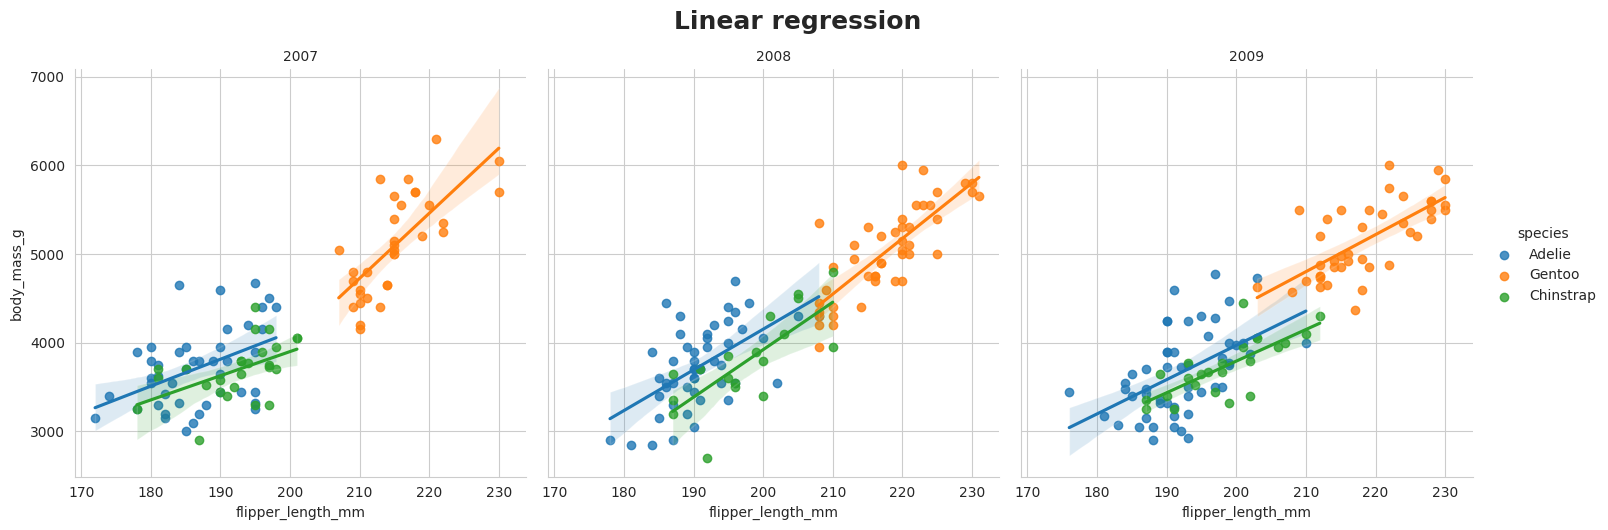

In [46]:
g = sns.lmplot(data, x='flipper_length_mm', y='body_mass_g', hue='species', col='year', col_wrap=3)
g.set_titles('{col_name}')
g.fig.suptitle('Linear regression', fontsize=18, fontweight='bold', y=1.05)
plt.show()

# Linear Regression

In [54]:
model1 = smf.ols('body_mass_g ~ flipper_length_mm', data).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1060.
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          3.13e-105
Time:                        22:54:14   Log-Likelihood:                -2461.1
No. Observations:                 333   AIC:                             4926.
Df Residuals:                     331   BIC:                             4934.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5872.0927    310.28

In [55]:
model2 = smf.ols('body_mass_g ~ flipper_length_mm + species', data).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.787
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     405.3
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          4.14e-110
Time:                        23:02:41   Log-Likelihood:                -2442.6
No. Observations:                 333   AIC:                             4893.
Df Residuals:                     329   BIC:                             4908.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -4013.1789 

In [57]:
model3 = smf.ols('body_mass_g ~ flipper_length_mm + species + year', data).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     321.1
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          4.98e-112
Time:                        23:04:17   Log-Likelihood:                -2435.0
No. Observations:                 333   AIC:                             4880.
Df Residuals:                     328   BIC:                             4899.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1.985e+05 

In [58]:
model4 = smf.ols('body_mass_g ~ flipper_length_mm + species + year + bill_length_mm + bill_depth_mm + island', data).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     235.2
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          5.15e-130
Time:                        23:07:05   Log-Likelihood:                -2380.8
No. Observations:                 333   AIC:                             4780.
Df Residuals:                     324   BIC:                             4814.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1.091e+05 

In [59]:
model5 = smf.ols('body_mass_g ~ flipper_length_mm + species + year + bill_length_mm + bill_depth_mm', data).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     313.1
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          4.77e-132
Time:                        23:08:19   Log-Likelihood:                -2381.9
No. Observations:                 333   AIC:                             4778.
Df Residuals:                     326   BIC:                             4804.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1.054e+05 

In [65]:
model6 = smf.ols('body_mass_g ~ flipper_length_mm + species + bill_length_mm + bill_depth_mm', data).fit()
print(model6.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     369.1
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          4.22e-132
Time:                        23:12:48   Log-Likelihood:                -2384.8
No. Observations:                 333   AIC:                             4782.
Df Residuals:                     327   BIC:                             4805.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -4282.0802 

In [78]:
np.sqrt(model5.mse_resid)

np.float64(312.46204364419003)